# 초기화
- 모든 가중치가 동일한경우, 여러 노드를 갖는 의미가 사라짐

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)

In [16]:
def run_experiment(input_data, node_num, hidden_layer_size, weight_scale_fn, act_fn, seed=0):
    rng = np.random.default_rng(seed)

    activations = {}
    x = input_data

    for i in range(hidden_layer_size):
        w = rng.standard_normal((node_num, node_num)) * weight_scale_fn(node_num)
        a = np.dot(x, w)
        z = act_fn(a)

        activations[i] = z
        x = z

    return activations
    

## 초기화 
- 앞층 노드 수에 따른 초기화 
- 자비에 초기화 $$\sqrt\frac{1}{ n}$$
- 헤 초기화 $$\sqrt\frac{2}{ n}$$

In [17]:
seed = 0
rng = np.random.default_rng(seed)

input_data = rng.standard_normal((1000, 100))
node_num = 100
hidden_layer_size = 5

weight_inits = {
    "std=1": lambda n: 1,
    "std=0.01": lambda n: 0.01,
    "Xavier sqrt(1/n)": lambda n: np.sqrt(1.0 / n),
    "He sqrt(2/n)": lambda n: np.sqrt(2.0 / n),
}

activation_fns = {
    "sigmoid": sigmoid,
    "ReLU": ReLU,
    "tanh": tanh,
}


In [18]:
results = {}

for init_name, scale_fn in weight_inits.items():
    for act_name, act_fn in activation_fns.items():
        key = f"{init_name} / {act_name}"
        results[key] = run_experiment(
            input_data=input_data,
            node_num=node_num,
            hidden_layer_size=hidden_layer_size,
            weight_scale_fn=scale_fn,
            act_fn=act_fn,
            seed=seed,
        )
        

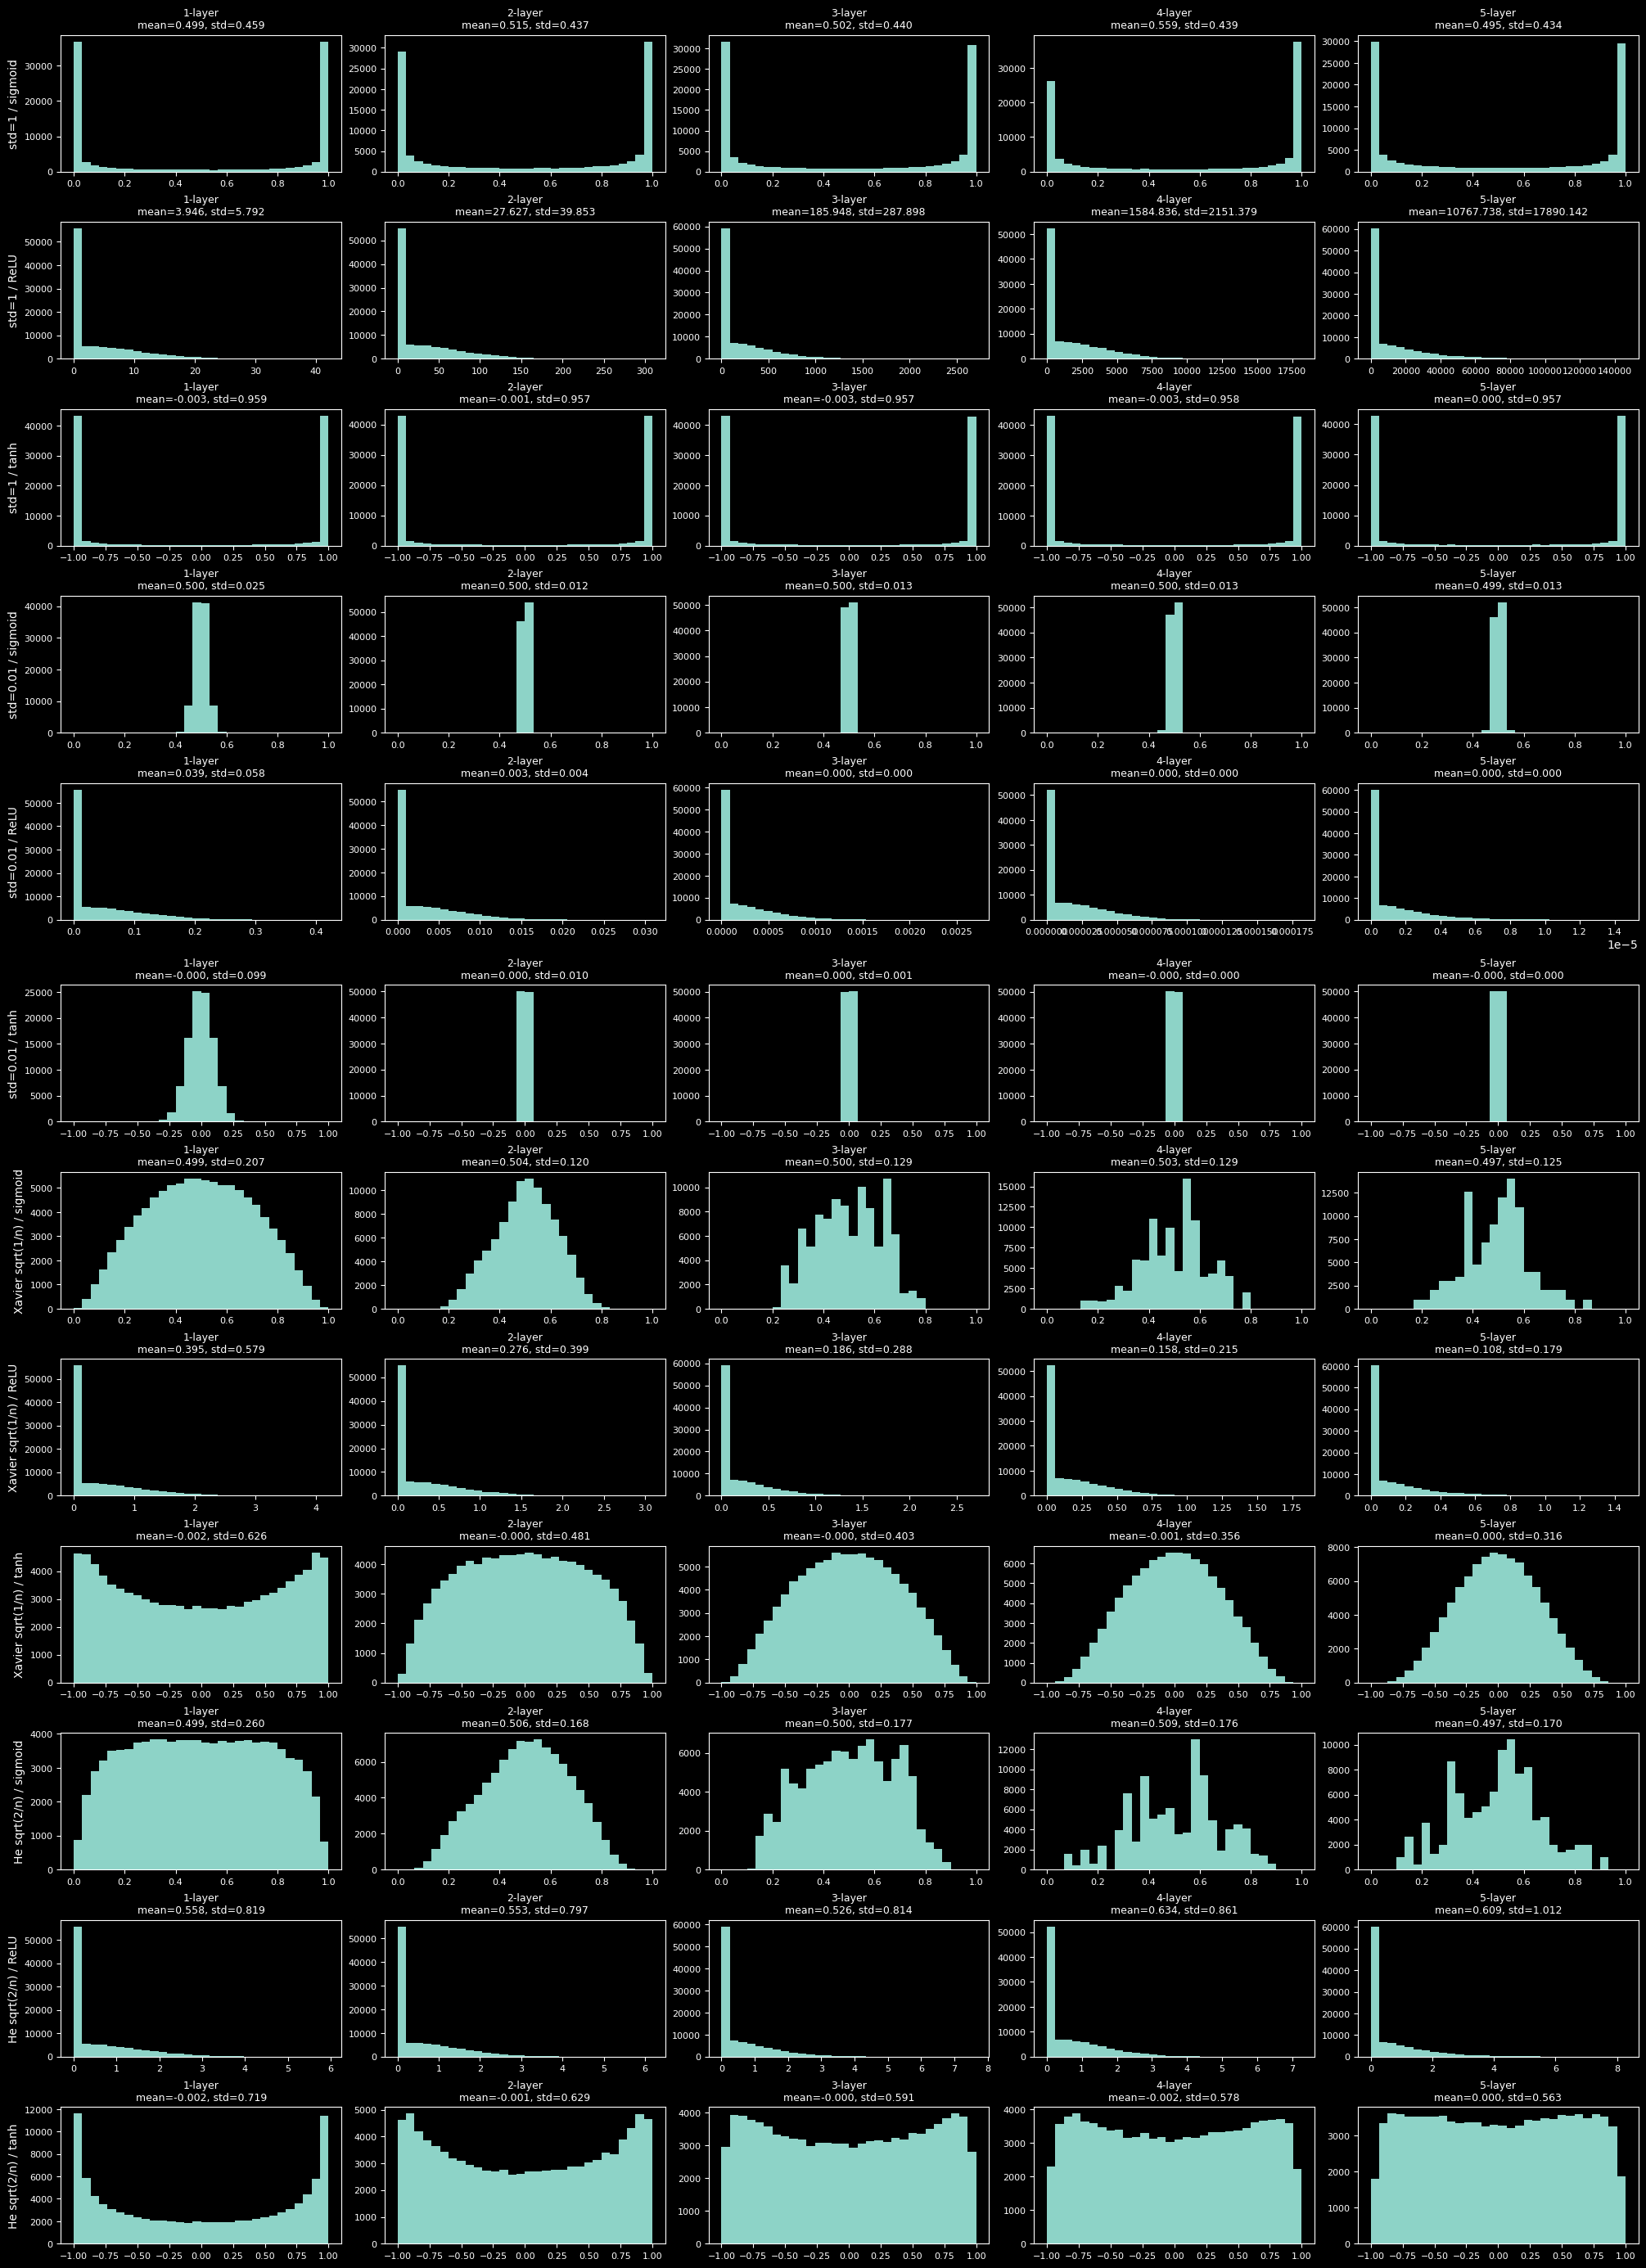

In [19]:
rows = len(results)
cols = hidden_layer_size

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(cols * 4, rows * 2.3),
    constrained_layout=True,
)

for row_idx, (setting_name, activations) in enumerate(results.items()):
    for col_idx in range(cols):
        ax = axes[row_idx, col_idx]
        data = activations[col_idx].flatten()

        if "sigmoid" in setting_name:
            hist_range = (0, 1)
        elif "tanh" in setting_name:
            hist_range = (-1, 1)
        else:
            hist_range = None

        ax.hist(data, bins=30, range=hist_range)

        mean = data.mean()
        std = data.std()

        ax.set_title(
            f"{col_idx + 1}-layer\nmean={mean:.3f}, std={std:.3f}",
            fontsize=9,
        )

        if col_idx == 0:
            ax.set_ylabel(setting_name, fontsize=10)

        ax.tick_params(labelsize=8)

plt.show()

100%|██████████| 2000/2000 [00:37<00:00, 52.78it/s, iteration=1900, std=0.01=2.305, std=0.1=0.361, Xavier=0.313, He=0.218]


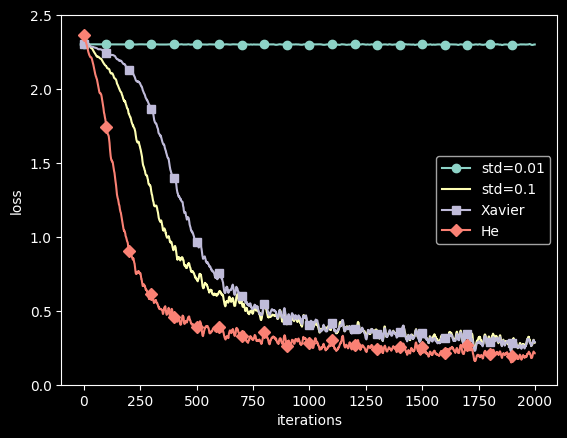

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

from datasets.mnist import load_mnist
from b1.utils.fuction import smooth_curve
from b1.module.multi_layer_net import MultiLayerNet
from b1.module.optimizer import SGD


(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


weight_init_types = {"std=0.01": 0.01, "std=0.1": 0.1, "Xavier": "sigmoid", "He": "relu"}
optimizer = SGD(lr=0.01)

networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(
        input_size=784,
        hidden_size_list=[100, 100, 100, 100],
        output_size=10,
        weight_init_std=weight_type,
    )
    train_loss[key] = []

pbar = tqdm(range(max_iterations))
for i in pbar:
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    for k in weight_init_types.keys():
        grads = networks[k].gradient(x_batch, t_batch)
        optimizer.update(networks[k].params, grads)

        loss = networks[k].loss(x_batch, t_batch)
        train_loss[k].append(loss)
        
    if i % 100 == 0:
        loss_dict = {"iteration": str(i)}
        for k in weight_init_types.keys():
            loss = networks[k].loss(x_batch, t_batch)
            loss_dict[k] = f"{loss:.3f}"
        pbar.set_postfix(loss_dict)


markers = {"std=0.01": "o", "std=0.1": ",", "Xavier": "s", "He": "D"}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(
        x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key
    )
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()